In [1]:
!git clone https://github.com/yunsuxiaozi/Yunbase.git

Cloning into 'Yunbase'...
remote: Enumerating objects: 350, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 350 (delta 21), reused 27 (delta 12), pack-reused 312 (from 1)
Receiving objects: 100% (350/350), 829.00 KiB | 12.95 MiB/s, done.
Resolving deltas: 100% (207/207), done.


In [2]:
!pip download -r Yunbase/requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 16.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.9/101.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.3/34.3 MB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 82.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 4.0 MB/s eta 0:00:00
  

In [3]:
source_file_path = '/kaggle/working/Yunbase/baseline.py'
target_file_path = '/kaggle/working/baseline.py'
with open(source_file_path, 'r', encoding='utf-8') as file:
    content = file.read()
with open(target_file_path, 'w', encoding='utf-8') as file:
    file.write(content)

In [4]:
!pip install -q --requirement /kaggle/working/Yunbase/requirements.txt  \
--no-index --find-links file:.

  Preparing metadata (setup.py) ... done


In [5]:
from baseline import Yunbase
import pandas as pd#read csv,parquet
import numpy as np#for scientific computation of matrices
from  lightgbm import LGBMRegressor,LGBMClassifier,log_evaluation,early_stopping
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer#word2vec feature
import warnings#avoid some negligible errors
#The filterwarnings () method is used to set warning filters, which can control the output method and level of warning information.
warnings.filterwarnings('ignore')
import random#provide some function to generate random_seed.
#set random seed,to make sure model can be recurrented.
def seed_everything(seed):
    np.random.seed(seed)#numpy's random seed
    random.seed(seed)#python built-in random seed
seed_everything(seed=2025)

In [6]:
# Feature Engineering
def get_feats(mode='train'):
    path = f'/kaggle/input/phems-hackathon-early-sepsis-prediction/{mode}ing_data/'
    feats = pd.read_csv(path + f"SepsisLabel_{mode}.csv").drop_duplicates()
    feats['measurement_datetime_day'] = feats['measurement_datetime'].fillna('None').astype(str).apply(lambda x: x[:10])

    # Drug Features
    drug = pd.read_csv(path + f"drugsexposure_{mode}.csv")
    drug['measurement_datetime_day'] = drug['drug_datetime_hourly'].fillna('None').astype(str).apply(lambda x: x[:10])
    for col in ['drug_concept_id', 'route_concept_id']:
        drug[col] = drug[col].fillna('None').astype(str)
        group_df = drug.groupby(['person_id', 'measurement_datetime_day'])[col].apply(lambda x: " ".join(x)).reset_index()
        feats = feats.merge(group_df, on=['person_id', 'measurement_datetime_day'], how='left')
        feats[col] = feats[col].fillna('None')

    # Time-Based Features
    feats['measurement_datetime'] = pd.to_datetime(feats['measurement_datetime'])
    feats['dow'] = feats['measurement_datetime'].dt.dayofweek
    feats['doy'] = feats['measurement_datetime'].dt.dayofyear
    feats['hour'] = feats['measurement_datetime'].dt.hour
    feats.drop(['measurement_datetime'], axis=1, inplace=True)

    # Convert categorical columns to category dtype
    feats['measurement_datetime_day'] = feats['measurement_datetime_day'].astype('category')
    feats['drug_concept_id'] = feats['drug_concept_id'].astype('category')
    feats['route_concept_id'] = feats['route_concept_id'].astype('category')

    return feats

# Load Data
train = get_feats(mode='train')
test = get_feats(mode='test')

# TF-IDF for Text Features
text_cols = ['drug_concept_id', 'route_concept_id']
tfidf_models = []
for col in text_cols:
    tfidf = TfidfVectorizer(max_features=100, ngram_range=(1, 1))
    train_tfidf = tfidf.fit_transform(train[col])
    test_tfidf = tfidf.transform(test[col])

    # Convert sparse matrix to DataFrame
    train_tfidf_df = pd.DataFrame(train_tfidf.toarray(), columns=[f"{col}_tfidf_{i}" for i in range(train_tfidf.shape[1])])
    test_tfidf_df = pd.DataFrame(test_tfidf.toarray(), columns=[f"{col}_tfidf_{i}" for i in range(test_tfidf.shape[1])])

    # Reset index to align
    train_tfidf_df.index = train.index
    test_tfidf_df.index = test.index

    # Concatenate TF-IDF features with train/test
    train = pd.concat([train, train_tfidf_df], axis=1)
    test = pd.concat([test, test_tfidf_df], axis=1)

    # Drop original text columns
    train.drop(columns=[col], inplace=True)
    test.drop(columns=[col], inplace=True)



In [7]:
print(train)

         person_id  SepsisLabel measurement_datetime_day  dow    doy  hour  \
0        274096387            0               2024-12-03  1.0  338.0  20.0   
1       1719359031            0               2024-04-20  5.0  111.0   9.0   
2       2024544816            0               2021-07-14  2.0  195.0   7.0   
3        213710896            0               2022-05-24  1.0  144.0   7.0   
4       1335786468            0               2024-08-25  6.0  238.0  22.0   
...            ...          ...                      ...  ...    ...   ...   
331634  2046744557            0               2021-04-06  1.0   96.0  11.0   
331635   549216345            0               2022-08-25  3.0  237.0  16.0   
331636  2108571452            0               2021-01-04  0.0    4.0  22.0   
331637   523755820            0               2020-05-29  4.0  150.0  15.0   
331638  2046454293            0               2024-01-08  0.0    8.0   2.0   

        drug_concept_id_tfidf_0  drug_concept_id_tfidf_1  \
0  

In [8]:
import pandas as pd
import numpy as np
from lightgbm import LGBMClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import precision_recall_curve, auc
from datetime import datetime, timedelta
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve, auc, roc_curve, roc_auc_score, confusion_matrix


Fold 1:
Train Accuracy: 0.9998, Train Precision: 0.9945, Train Recall: 0.9965, Train F1: 0.9955
Validation Accuracy: 0.9787, Validation Precision: 0.5703, Validation Recall: 0.0509, Validation F1: 0.0934
--------------------------------------------------
Fold 2:
Train Accuracy: 0.9998, Train Precision: 0.9951, Train Recall: 0.9960, Train F1: 0.9956
Validation Accuracy: 0.9758, Validation Precision: 0.2848, Validation Recall: 0.1330, Validation F1: 0.1814
--------------------------------------------------
Fold 3:
Train Accuracy: 0.9998, Train Precision: 0.9955, Train Recall: 0.9951, Train F1: 0.9953
Validation Accuracy: 0.9783, Validation Precision: 0.1985, Validation Recall: 0.0199, Validation F1: 0.0361
--------------------------------------------------
Fold 4:
Train Accuracy: 0.9998, Train Precision: 0.9958, Train Recall: 0.9967, Train F1: 0.9963
Validation Accuracy: 0.9779, Validation Precision: 0.3083, Validation Recall: 0.0570, Validation F1: 0.0962
-------------------------------

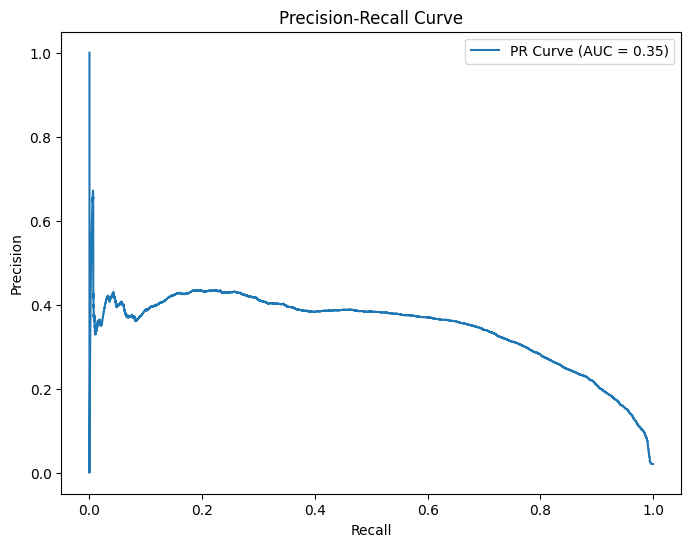

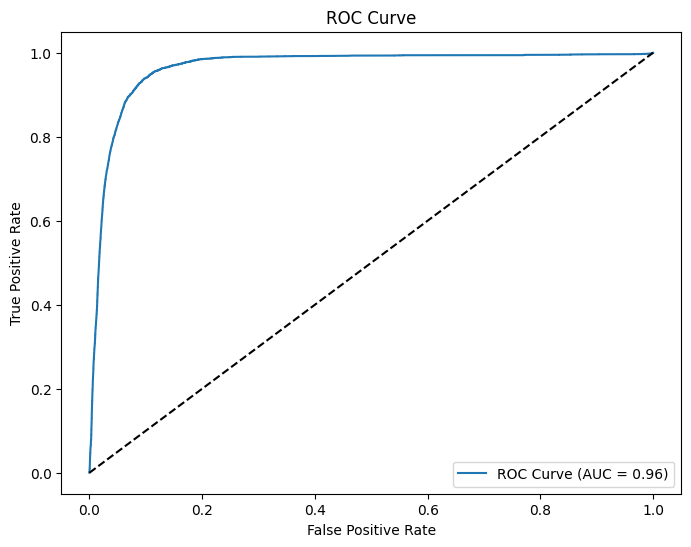

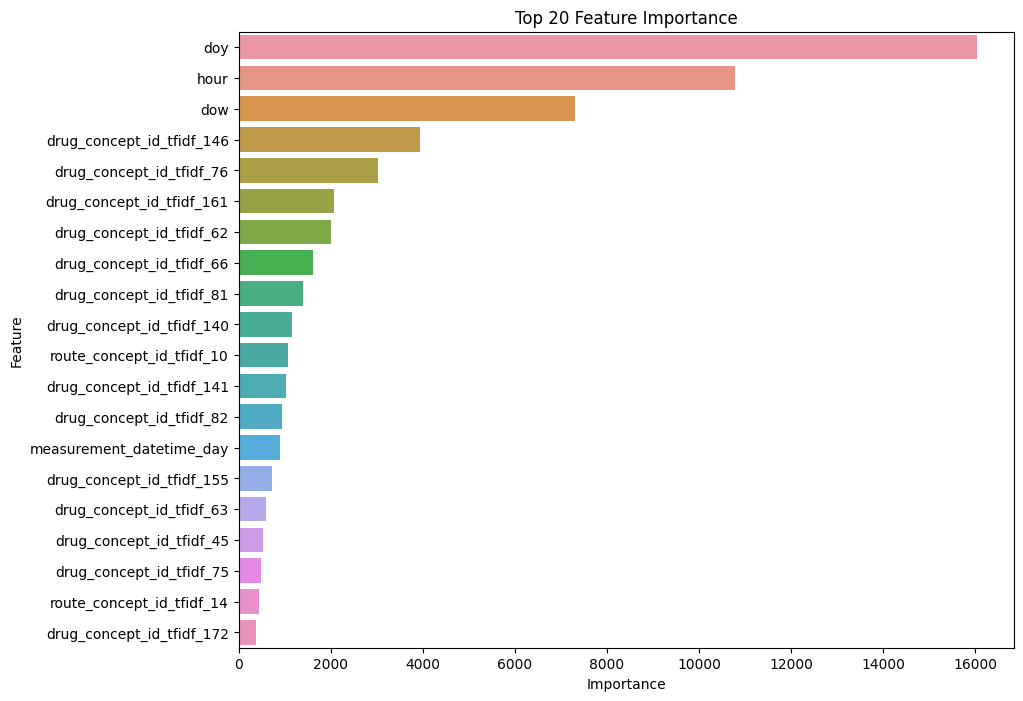

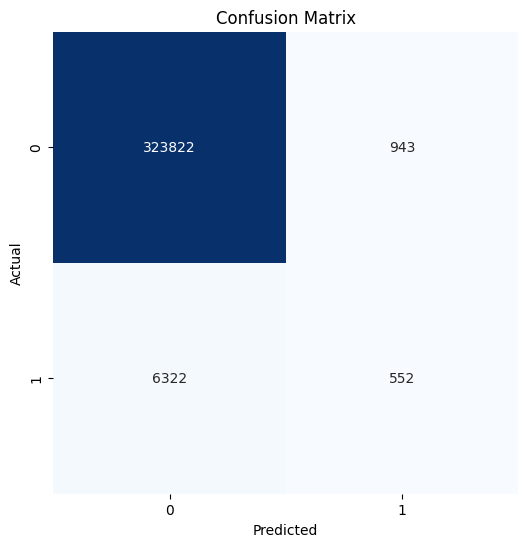

Submission file saved as 'submission.csv'


In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve, auc
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np

# Feature Engineering function (as provided)
def get_feats(mode='train'):
    path = f'/kaggle/input/phems-hackathon-early-sepsis-prediction/{mode}ing_data/'
    feats = pd.read_csv(path + f"SepsisLabel_{mode}.csv").drop_duplicates()
    feats['measurement_datetime_day'] = feats['measurement_datetime'].fillna('None').astype(str).apply(lambda x: x[:10])

    # Drug Features
    drug = pd.read_csv(path + f"drugsexposure_{mode}.csv")
    drug['measurement_datetime_day'] = drug['drug_datetime_hourly'].fillna('None').astype(str).apply(lambda x: x[:10])
    for col in ['drug_concept_id', 'route_concept_id']:
        drug[col] = drug[col].fillna('None').astype(str)
        group_df = drug.groupby(['person_id', 'measurement_datetime_day'])[col].apply(lambda x: " ".join(x)).reset_index()
        feats = feats.merge(group_df, on=['person_id', 'measurement_datetime_day'], how='left')
        feats[col] = feats[col].fillna('None')

    # Time-Based Features
    feats['measurement_datetime'] = pd.to_datetime(feats['measurement_datetime'])
    feats['dow'] = feats['measurement_datetime'].dt.dayofweek
    feats['doy'] = feats['measurement_datetime'].dt.dayofyear
    feats['hour'] = feats['measurement_datetime'].dt.hour
    feats.drop(['measurement_datetime'], axis=1, inplace=True)

    # Convert categorical columns to category dtype
    feats['measurement_datetime_day'] = feats['measurement_datetime_day'].astype('category')
    feats['drug_concept_id'] = feats['drug_concept_id'].astype('category')
    feats['route_concept_id'] = feats['route_concept_id'].astype('category')

    return feats

# Load Data
train = get_feats(mode='train')
test = get_feats(mode='test')
# Adding lag and difference features
# Time-based cyclic features

# Filter Rows for Training
# Keep the first 7,000 rows where SepsisLabel == 0


# TF-IDF for Text Features
text_cols = ['drug_concept_id', 'route_concept_id']
for col in text_cols:
    tfidf = TfidfVectorizer(max_features=200, ngram_range=(2, 2))
    train_tfidf = tfidf.fit_transform(train[col])
    test_tfidf = tfidf.transform(test[col])

    # Convert sparse matrix to DataFrame
    train_tfidf_df = pd.DataFrame(train_tfidf.toarray(), columns=[f"{col}_tfidf_{i}" for i in range(train_tfidf.shape[1])])
    test_tfidf_df = pd.DataFrame(test_tfidf.toarray(), columns=[f"{col}_tfidf_{i}" for i in range(test_tfidf.shape[1])])

    # Reset index to align
    train_tfidf_df.index = train.index
    test_tfidf_df.index = test.index

    # Concatenate TF-IDF features with train/test
    train = pd.concat([train, train_tfidf_df], axis=1)
    test = pd.concat([test, test_tfidf_df], axis=1)

    # Drop original text columns
    train.drop(columns=[col], inplace=True)
    test.drop(columns=[col], inplace=True)

# Define Model Parameters
lgb_params = {
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'max_depth': 200,
    'num_leaves': 713,
    'min_child_samples': 50,
    'min_child_weight': 0.001,
    'subsample': 0.9,
    'subsample_freq': 1,
    'colsample_bytree': 0.9,
    'colsample_bynode': 0.9,
    'reg_alpha': 0.0,
    'reg_lambda': 0.0,
    'objective': 'binary',
    'metric': 'auc',
    'is_unbalance': False,
    'scale_pos_weight': 1,
    'n_jobs': -1,
    'random_state': 2025,
    'bagging_fraction': 0.9,
    'bagging_freq': 1,
    'feature_fraction': 0.8,
    'lambda_l1': 0.0,
    'lambda_l2': 0.0,
    'max_bin': 255,
    'max_delta_step': 0,
    'min_split_gain': 0.0,
    'verbosity': -1,
    'seed': 2025,
    'deterministic': True
}

# Cross-Validation
sgkf = StratifiedGroupKFold(n_splits=5)
oof_preds = np.zeros(len(train))
test_preds = np.zeros(len(test))

features = [col for col in train.columns if col not in ['SepsisLabel', 'person_id']]

for fold, (train_idx, val_idx) in enumerate(sgkf.split(train, train['SepsisLabel'], groups=train['person_id'])):
    X_train, X_val = train.iloc[train_idx][features], train.iloc[val_idx][features]
    y_train, y_val = train.iloc[train_idx]['SepsisLabel'], train.iloc[val_idx]['SepsisLabel']

    model = LGBMClassifier(**lgb_params)
    model.fit(X_train, y_train)

    # Out-of-fold predictions for validation
    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    test_preds += model.predict_proba(test[features])[:, 1] / sgkf.n_splits

    # Print evaluation metrics on train and validation sets
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    print(f"Fold {fold + 1}:")

    # Training metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred)
    train_recall = recall_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred)

    # Validation metrics
    val_accuracy = accuracy_score(y_val, y_val_pred)
    val_precision = precision_score(y_val, y_val_pred)
    val_recall = recall_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred)

    print(f"Train Accuracy: {train_accuracy:.4f}, Train Precision: {train_precision:.4f}, Train Recall: {train_recall:.4f}, Train F1: {train_f1:.4f}")
    print(f"Validation Accuracy: {val_accuracy:.4f}, Validation Precision: {val_precision:.4f}, Validation Recall: {val_recall:.4f}, Validation F1: {val_f1:.4f}")
    print("-" * 50)

# Evaluate Model
precision, recall, _ = precision_recall_curve(train['SepsisLabel'], oof_preds)
pr_auc = auc(recall, precision)
print(f'PR-AUC: {pr_auc:.4f}')
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve, auc, roc_curve, roc_auc_score, confusion_matrix
roc_auc = roc_auc_score(train['SepsisLabel'], oof_preds)
# Plot Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.show()

# Plot ROC Curve
fpr, tpr, _ = roc_curve(train['SepsisLabel'], oof_preds)
roc_auc = roc_auc_score(train['SepsisLabel'], oof_preds)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='best')
plt.show()

# Plot Feature Importance
feature_importance = model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importance})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20))
plt.title('Top 20 Feature Importance')
plt.show()

# Plot Confusion Matrix
y_pred = (oof_preds > 0.5).astype(int)  # Convert probabilities to binary predictions
cm = confusion_matrix(train['SepsisLabel'], y_pred)

plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
# Submission
sub = pd.read_csv('/kaggle/input/phems-hackathon-early-sepsis-prediction/SepsisLabel_sample_submission.csv')
sub['SepsisLabel'] = test_preds
sub.to_csv('submission.csv', index=False)
print("Submission file saved as 'submission.csv'")


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


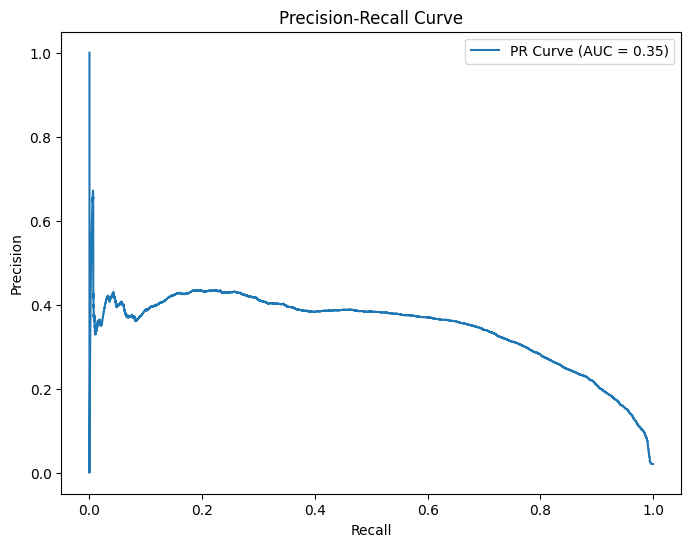

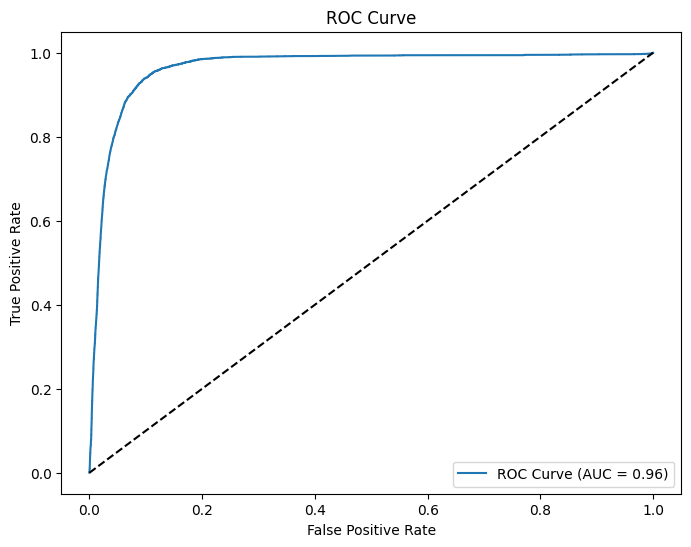

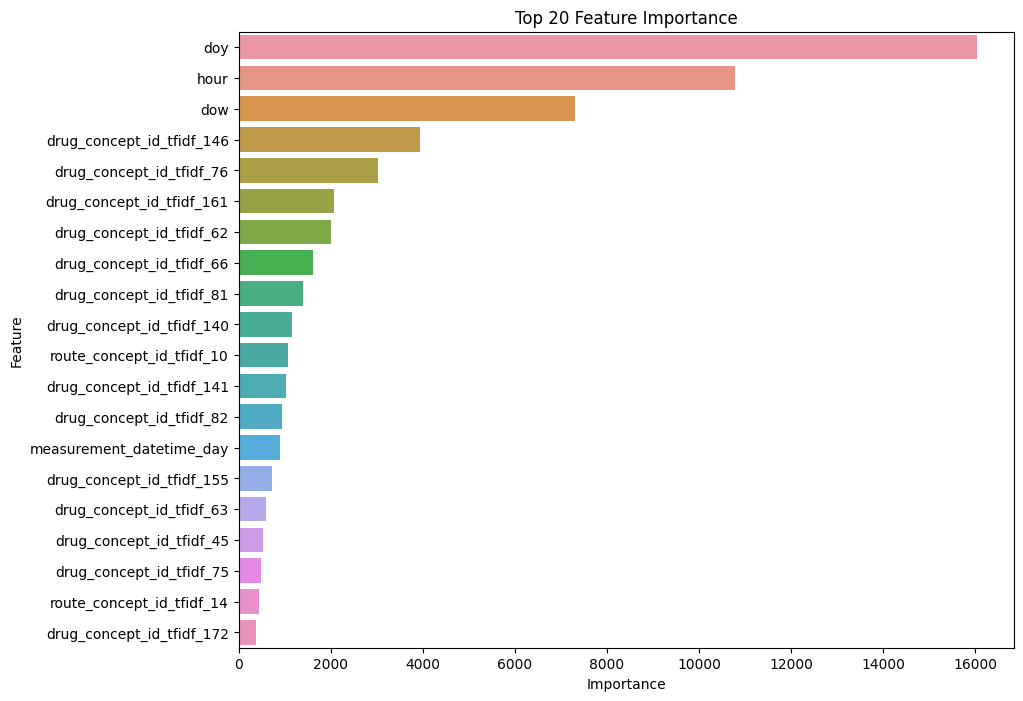

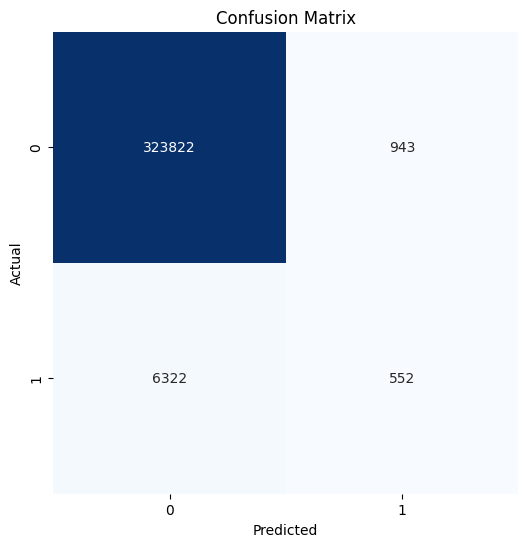

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve, auc, roc_curve, roc_auc_score, confusion_matrix
roc_auc = roc_auc_score(train['SepsisLabel'], oof_preds)
# Plot Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.show()

# Plot ROC Curve
fpr, tpr, _ = roc_curve(train['SepsisLabel'], oof_preds)
roc_auc = roc_auc_score(train['SepsisLabel'], oof_preds)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='best')
plt.show()

# Plot Feature Importance
feature_importance = model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importance})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20))
plt.title('Top 20 Feature Importance')
plt.show()

# Plot Confusion Matrix
y_pred = (oof_preds > 0.5).astype(int)  # Convert probabilities to binary predictions
cm = confusion_matrix(train['SepsisLabel'], y_pred)

plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


# <span><h1 style = "font-family: garamond; font-size: 40px; font-style: normal; letter-spcaing: 3px; background-color: #f6f5f5; color :#fe346e; border-radius: 100px 100px; text-align:center">2.Construct features</h1></span>

Through experiments, it was found that the two features 'drug_comept_id' and 'route__comept_id 'are particularly important for the final prediction, so here we mainly construct their related features. Due to the possibility of multiple 'measurement_datetime' for a 'person_id', we will refine 'measurement_datetime' to days and then search for the data of each day and the previous day to construct features.

# <span><h1 style = "font-family: garamond; font-size: 40px; font-style: normal; letter-spcaing: 3px; background-color: #f6f5f5; color :#fe346e; border-radius: 100px 100px; text-align:center">3.Train and Predict</h1></span>


- 'weight' is a weighted training for each sample.

- word2vec_madels is a tfidf model used to construct tfidf features for text data.

Due to an imbalanced sample in this competition,here we will use repeatgroupkfold (n_repeats=2,group_col='person_id') to train lightgbm model.

We can see that the CV  fluctuates greatly and differs significantly from LB. I estimate that there will be a significant shakeup in this competition.

Good luck to everyone.